# Titanic Survival Prediction

## CodSoft Data Science Internship – Task 1

This project uses the Titanic dataset to build a machine learning model
that predicts whether a passenger survived or not.

The project includes data exploration, preprocessing, visualization,
model training, and evaluation.


## 1. Importing Required Libraries

The following Python libraries are used for data manipulation,
visualization, and machine learning.

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Loading the Dataset

The Titanic dataset is uploaded and loaded into a Pandas DataFrame
for further analysis and preprocessing.

In [88]:
from google.colab import files

uploaded = files.upload()

Saving Titanic-Dataset.csv to Titanic-Dataset (2).csv


In [89]:
filename = next(iter(uploaded))

df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("File used:", filename)

Dataset loaded successfully!
File used: Titanic-Dataset (2).csv


In [90]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [92]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Number of rows: 891
Number of columns: 12

Column names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [93]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [94]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [95]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the distribution
of passenger information and identify patterns related to survival.         

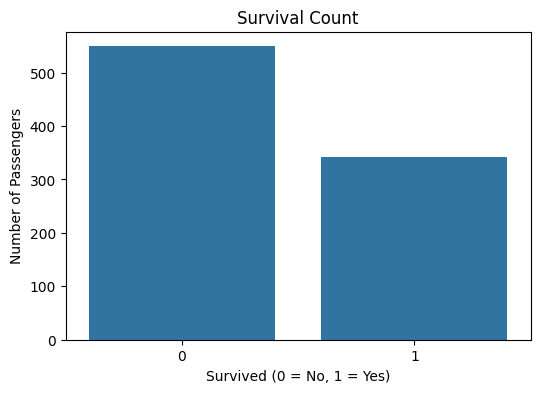

In [96]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Survived")
plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()

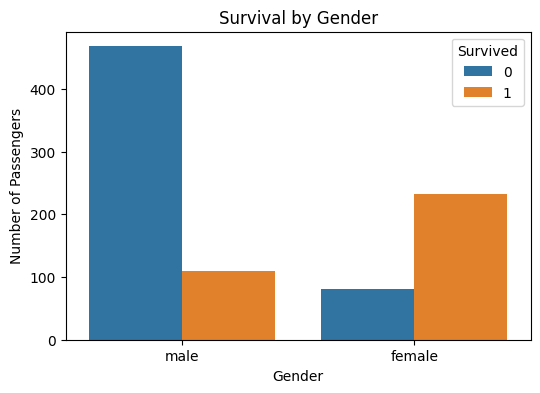

In [97]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Sex", hue="Survived")
plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.show()

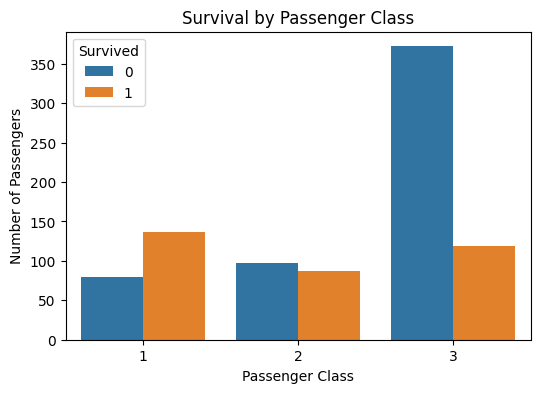

In [98]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Pclass", hue="Survived")
plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.show()

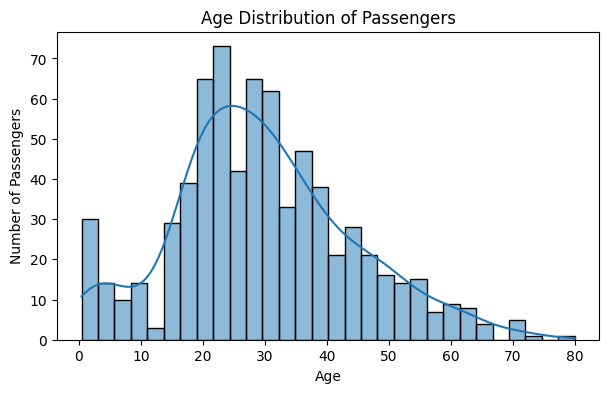

In [99]:
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="Age", bins=30, kde=True)
plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

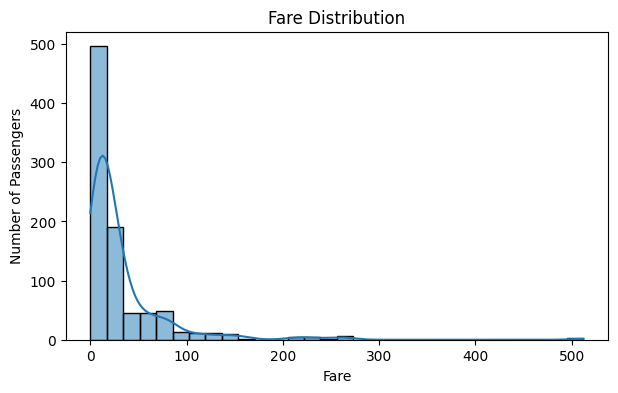

In [100]:
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="Fare", bins=30, kde=True)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")
plt.show()

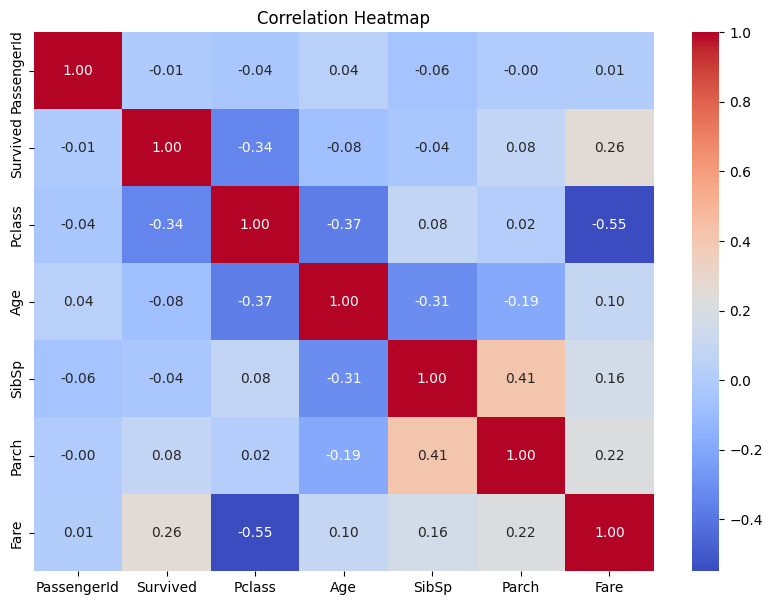

In [101]:
plt.figure(figsize=(10, 7))
correlation = df.select_dtypes(include="number").corr()

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## Data Preprocessing

The dataset is cleaned and prepared for machine learning by removing
unnecessary columns, handling missing values, and converting categorical
variables into numerical features.

In [102]:
df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

print("Remaining columns:")
print(df.columns.tolist())

Remaining columns:
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [103]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

print("Missing values after preprocessing:")
print(df.isnull().sum())

Missing values after preprocessing:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [104]:
df = pd.get_dummies(df, columns=["Sex", "Embarked"], drop_first=True)

print("Columns after encoding:")
print(df.columns.tolist())

Columns after encoding:
['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']


## Model Training

The processed dataset is divided into training and testing sets.
A Logistic Regression model is then trained to predict passenger survival.

In [105]:
# Separate features and target

X = df.drop(columns=["Survived"])
y = df["Survived"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (891, 8)
Target shape: (891,)


In [106]:
print("Feature data types:")
print(X.dtypes)

Feature data types:
Pclass          int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Sex_male         bool
Embarked_Q       bool
Embarked_S       bool
dtype: object


In [107]:
# Convert only Boolean columns to integers

bool_columns = X.select_dtypes(include="bool").columns
X[bool_columns] = X[bool_columns].astype(int)

print("Updated feature data types:")
print(X.dtypes)

Updated feature data types:
Pclass          int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Sex_male        int64
Embarked_Q      int64
Embarked_S      int64
dtype: object


In [108]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (712, 8)
Testing data: (179, 8)


In [109]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [110]:
y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print("First 10 predictions:", y_pred[:10])

Predictions generated successfully!
First 10 predictions: [0 0 0 0 1 0 1 0 0 0]


In [111]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Model Accuracy (%):", accuracy * 100)

Model Accuracy: 0.8044692737430168
Model Accuracy (%): 80.44692737430168


In [112]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [113]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[98 12]
 [23 46]]


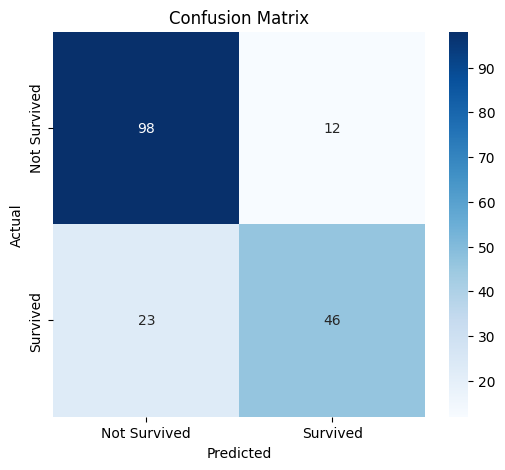

In [114]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Survived", "Survived"],
    yticklabels=["Not Survived", "Survived"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [115]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

print("Feature coefficients:")
print(coefficients)

Feature coefficients:
      Feature  Coefficient
6  Embarked_Q     0.278320
4        Fare     0.002255
1         Age    -0.038464
3       Parch    -0.071496
2       SibSp    -0.243809
7  Embarked_S    -0.381616
0      Pclass    -1.090476
5    Sex_male    -2.555755


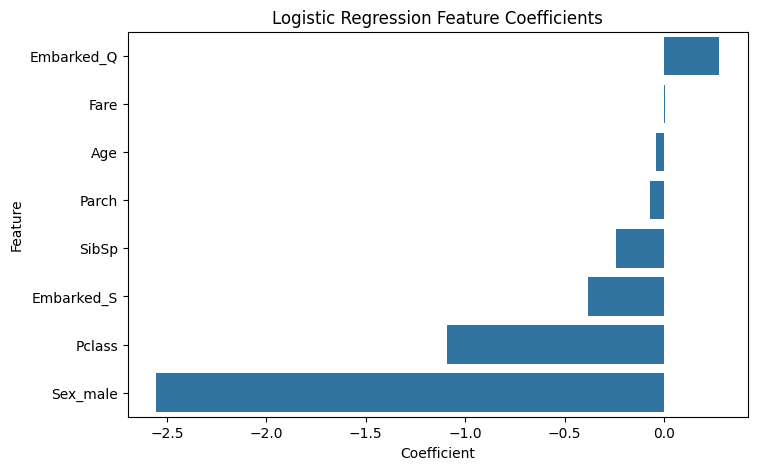

In [116]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=coefficients,
    x="Coefficient",
    y="Feature"
)

plt.title("Logistic Regression Feature Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

## Making a Prediction on a New Passenger

The trained Logistic Regression model is used to predict the survival
outcome of a new passenger based on their characteristics.

In [117]:
new_passenger = pd.DataFrame({
    "Pclass": [3],
    "Age": [22.0],
    "SibSp": [1],
    "Parch": [0],
    "Fare": [7.25],
    "Sex_male": [1],
    "Embarked_Q": [0],
    "Embarked_S": [1]
})

prediction = model.predict(new_passenger)

print("Predicted Survival:", prediction[0])

if prediction[0] == 1:
    print("Prediction: Passenger is likely to survive.")
else:
    print("Prediction: Passenger is likely not to survive.")

Predicted Survival: 0
Prediction: Passenger is likely not to survive.


In [118]:
print("New Passenger Details:")
print(new_passenger)

New Passenger Details:
   Pclass   Age  SibSp  Parch  Fare  Sex_male  Embarked_Q  Embarked_S
0       3  22.0      1      0  7.25         1           0           1


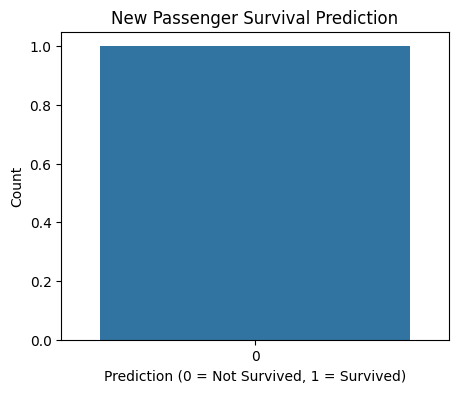

In [119]:
plt.figure(figsize=(5, 4))

sns.countplot(x=prediction)

plt.title("New Passenger Survival Prediction")
plt.xlabel("Prediction (0 = Not Survived, 1 = Survived)")
plt.ylabel("Count")
plt.show()

## Model Performance

The Logistic Regression model was trained to predict whether a Titanic passenger survived or not.

- **Model:** Logistic Regression
- **Test Accuracy:** 80.45%
- **Classes:** 0 = Not Survived, 1 = Survived
- **Evaluation:** Accuracy, Classification Report, and Confusion Matrix

## Conclusion

The Titanic Survival Prediction project successfully used machine learning
to predict passenger survival based on features such as passenger class,
age, gender, family information, fare, and port of embarkation.

The Logistic Regression model achieved a test accuracy of approximately
80.45%. The classification report and confusion matrix were used to
evaluate the model's performance.

The model was also tested on a new passenger example and predicted that
the passenger would not survive.

## Project Workflow

1. Load the Titanic dataset
2. Understand and explore the data
3. Perform data visualization
4. Handle missing values
5. Encode categorical features
6. Split the data into training and testing sets
7. Train the Logistic Regression model
8. Evaluate the model
9. Predict survival for a new passenger
10. Draw conclusions